# Objective:
## To test whether implementing a retry payment feature significantly reduces payment dropouts across multiple payment methods.

1. Primary Hypothesis 
    Null Hypothesis (H₀): Retry feature does not reduce payment dropouts.

    Alternative Hypothesis (H₁): Retry feature reduces payment dropouts.

2. Secondary Hypothesis
    H₀: Retry success rate = First attempt success rate

    H₁: Retry success rate ≠ First attempt success rate



In [33]:
import pandas as pd
import numpy as np

# Load data into a DataFrame
df = pd.read_csv('payment_retry_data.csv')

df.head()



,user_id,group,payment_method,first_attempt_success,retry_prompt_shown,retry_clicked,retry_success,final_success
0,221958,test,UPI,True,False,False,False,True
1,744167,control,UPI,True,False,False,False,True
2,621430,control,Netbanking,False,False,False,False,False
3,275203,test,Netbanking,True,False,False,False,True
4,887201,test,Debit Card,True,False,False,False,True


## Sample Size calculation

In [34]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

alpha = 0.05        # significance level
power = 0.80        # statistical power
mde = 0.05  # minimum detectable effect size (3% improvement in dropout rate)   


# Filter control group
control_df = df[df['group'] == 'control']

# Baseline dropout = % of users who failed the first attempt and never succeeded
n_control = len(control_df)
dropouts = control_df[(control_df['first_attempt_success'] == False) & 
                      (control_df['final_success'] == False)]

baseline_dropout_rate = len(dropouts) / n_control

print(f"Empirical Baseline Dropout Rate (control group): {baseline_dropout_rate:.4f}")

target_dropout_rate= baseline_dropout_rate - mde  # expected improvement

print("Baseline dropout rate:", baseline_dropout_rate)
print("Target dropout rate:", target_dropout_rate)

# Plug into power analysis
effect_size = proportion_effectsize(baseline_dropout_rate, target_dropout_rate)


# Calculate required sample size per group
analysis = NormalIndPower()
sample_size = analysis.solve_power(effect_size=effect_size,
                                   alpha=alpha,
                                   power=power,
                                   alternative='smaller')  # one-sided test
sample_size = math.ceil(sample_size)

# Step 4: Print results
print(f"Required sample size per group: {sample_size}")
print(f"Total required sample size (control + test): {2 * sample_size}")


Empirical Baseline Dropout Rate (control group): 0.1479
Baseline dropout rate: 0.14785530737299862
Target dropout rate: 0.09785530737299862
Required sample size per group: 10
Total required sample size (control + test): 20


c:\Users\jshre\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\power.py:135: RuntimeWarning: invalid value encountered in sqrt
  pow_ += stats.norm.cdf(crit - d*np.sqrt(nobs)/sigma)
C:\Users\jshre\AppData\Local\Temp\ipykernel_9064\2126511642.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sample_size = math.ceil(sample_size)


## Data Cleaning

In [35]:
import pandas as pd

# Assuming 'df' is your synthetic dataset
# Step 1: Remove duplicates (based on user_id)
df_clean = df.drop_duplicates(subset='user_id')
print(f"Removed duplicates. Remaining rows: {len(df_clean)}")

# Step 2: Remove rows with any missing values
df_clean = df_clean.dropna()
print(f"Removed rows with missing values. Remaining rows: {len(df_clean)}")

# Step 3: Validate group assignment
group_counts = df_clean['group'].value_counts()
print("\nGroup Distribution:")
print(group_counts)

# Step 4: Ensure users exist in only one group
# (Already ensured by drop_duplicates on user_id, but reconfirming)
group_check = df_clean.groupby('user_id')['group'].nunique()
users_in_multiple_groups = group_check[group_check > 1]
if len(users_in_multiple_groups) > 0:
    print(f"Warning: {len(users_in_multiple_groups)} users found in both groups!")
    df_clean = df_clean[~df_clean['user_id'].isin(users_in_multiple_groups.index)]
else:
    print("All users belong to exactly one group.")

# Step 5: Validate sample sizes per payment method per group
pivot_counts = df_clean.pivot_table(index='payment_method', 
                                     columns='group', 
                                     aggfunc='size', 
                                     fill_value=0)
print("\nSample Count by Payment Method and Group:")
print(pivot_counts)

# Optional: Reset index for easier use in modeling later
df_clean = df_clean.reset_index(drop=True)


Removed duplicates. Remaining rows: 9946
Removed rows with missing values. Remaining rows: 9946

Group Distribution:
group
control    5032
test       4914
Name: count, dtype: int64
All users belong to exactly one group.

Sample Count by Payment Method and Group:
group           control  test
payment_method               
Debit Card         1656  1661
Netbanking         1738  1636
UPI                1638  1617


## EDA

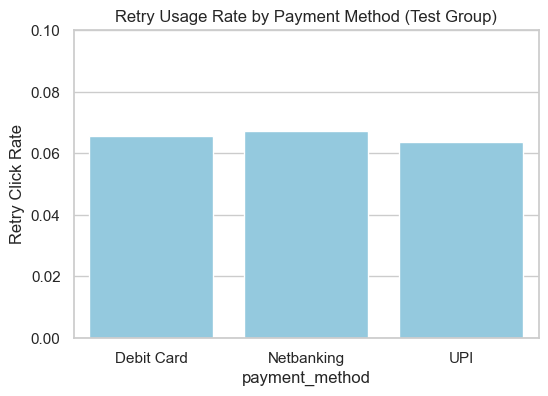

C:\Users\jshre\AppData\Local\Temp\ipykernel_9064\2531484345.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_by_group, x='group', y='final_success', palette='pastel')


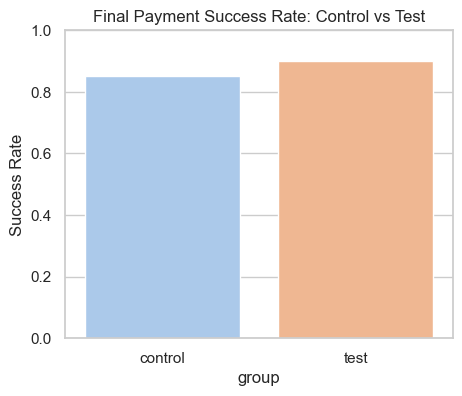

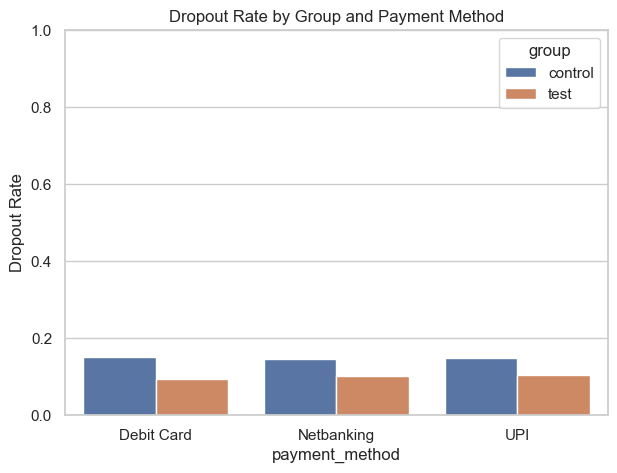

C:\Users\jshre\AppData\Local\Temp\ipykernel_9064\2531484345.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=funnel_summary, x='Stage', y='Rate', palette='Blues')


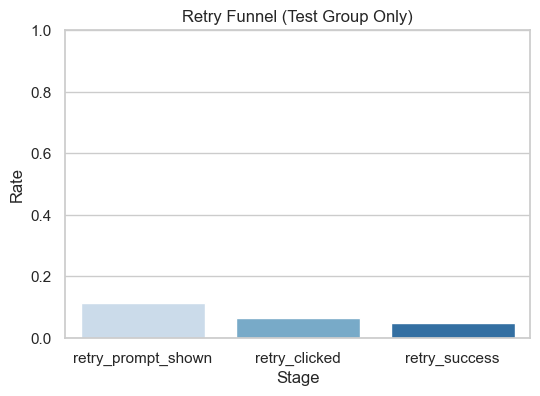

C:\Users\jshre\AppData\Local\Temp\ipykernel_9064\2531484345.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Stage', y='Success Rate', palette='Set2')


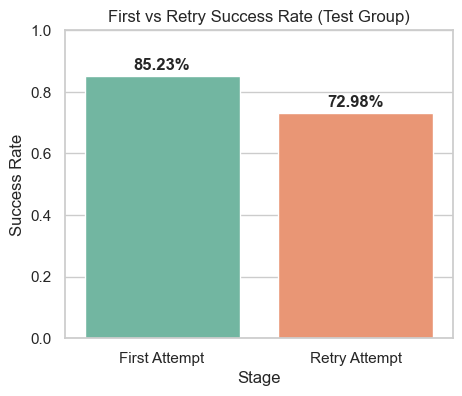

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set plot style
sns.set(style="whitegrid")

# 1. Retry usage rate in test group by payment method
test_df = df_clean[df_clean['group'] == 'test']
retry_usage = test_df.groupby('payment_method')['retry_clicked'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=retry_usage, x='payment_method', y='retry_clicked', color='skyblue')
plt.title("Retry Usage Rate by Payment Method (Test Group)")
plt.ylabel("Retry Click Rate")
plt.ylim(0, 0.1)
plt.show()

# 2. Final success rate: control vs test
success_by_group = df_clean.groupby('group')['final_success'].mean().reset_index()

plt.figure(figsize=(5, 4))
sns.barplot(data=success_by_group, x='group', y='final_success', palette='pastel')
plt.title("Final Payment Success Rate: Control vs Test")
plt.ylabel("Success Rate")
plt.ylim(0, 1)
plt.show()

# 3. Dropout rate by group and payment method
df_clean['dropout'] = (~df_clean['final_success']).astype(int)
dropout_rates = df_clean.groupby(['group', 'payment_method'])['dropout'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=dropout_rates, x='payment_method', y='dropout', hue='group')
plt.title("Dropout Rate by Group and Payment Method")
plt.ylabel("Dropout Rate")
plt.ylim(0, 1)
plt.show()

# 4. Retry funnel conversion in test group
funnel_summary = test_df.agg({
    'retry_prompt_shown': 'mean',
    'retry_clicked': 'mean',
    'retry_success': 'mean'
}).to_frame(name='Rate').reset_index().rename(columns={'index': 'Stage'})

plt.figure(figsize=(6, 4))
sns.barplot(data=funnel_summary, x='Stage', y='Rate', palette='Blues')
plt.title("Retry Funnel (Test Group Only)")
plt.ylim(0, 1)
plt.show()

# 5. First vs Retry Success Rate (Test Group Only)
first_attempt_rate = test_df['first_attempt_success'].mean()
retry_success_rate = test_df.loc[test_df['retry_clicked'], 'retry_success'].mean()

comparison_df = pd.DataFrame({
    'Stage': ['First Attempt', 'Retry Attempt'],
    'Success Rate': [first_attempt_rate, retry_success_rate]
})

plt.figure(figsize=(5, 4))
sns.barplot(data=comparison_df, x='Stage', y='Success Rate', palette='Set2')
# Add labels
for i, value in enumerate(comparison_df['Success Rate']):
    plt.text(i, value + 0.02, f"{value:.2%}", ha='center', fontweight='bold')


plt.title("First vs Retry Success Rate (Test Group)")
plt.ylim(0, 1)
plt.show()


## One-Sided Z-Test for Proportions

In [37]:
from statsmodels.stats.proportion import proportions_ztest

# Create dropout flag if not already created
df_clean['dropout'] = (~df_clean['final_success']).astype(int)

# Group-wise dropout counts
dropout_counts = df_clean.groupby('group')['dropout'].agg(['sum', 'count'])

control_dropouts = dropout_counts.loc['control', 'sum']
control_total = dropout_counts.loc['control', 'count']

test_dropouts = dropout_counts.loc['test', 'sum']
test_total = dropout_counts.loc['test', 'count']

# Proportions
control_rate = control_dropouts / control_total
test_rate = test_dropouts / test_total

print(f"Control Dropout Rate: {control_rate:.4f}")
print(f"Test Dropout Rate:    {test_rate:.4f}")

# Perform one-sided Z-test
count = np.array([control_dropouts, test_dropouts])
nobs = np.array([control_total, test_total])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value (one-sided): {p_value:.4f}")

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("✅ Result: Statistically significant. Retry feature reduces dropout.")
else:
    print("❌ Result: Not statistically significant. No clear impact from retry.")


Control Dropout Rate: 0.1481
Test Dropout Rate:    0.0999

Z-statistic: 7.2752
P-value (one-sided): 0.0000
✅ Result: Statistically significant. Retry feature reduces dropout.


## Chi-square Independence Test (Retry Clicked vs Final Success)

In [38]:
import pandas as pd
from scipy.stats import chi2_contingency

# Filter test group only (only they see retry)
test_df = df_clean[df_clean['group'] == 'test']

# Create 2x2 contingency table: Retry Clicked vs Final Success
contingency_table = pd.crosstab(test_df['retry_clicked'], test_df['final_success'])
 
print("Contingency Table (Retry Clicked vs Final Success):\n")
print(contingency_table)

# Perform Chi-square test of independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("✅ Result: Significant association between retry usage and success.")
else:
    print("❌ Result: No significant association between retry usage and success.")


Contingency Table (Retry Clicked vs Final Success):

final_success  False  True 
retry_clicked              
False            404   4188
True              87    235

Chi-square Statistic: 109.0607
Degrees of Freedom: 1
P-value: 0.0000
✅ Result: Significant association between retry usage and success.


## Cohen’s h – Difference in Proportions (Control vs Test)

In [39]:
import numpy as np

# Dropout rates
p_control = control_rate  # from step 6.a
p_test = test_rate

# Cohen's h calculation
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

h = cohens_h(p_control, p_test)
print(f"Cohen's h: {h:.4f}")

# Interpretation thresholds (Cohen's guideline)
if abs(h) < 0.2:
    interpretation = "Small effect"
elif abs(h) < 0.5:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"
print(f"Effect Size Interpretation: {interpretation}")


Cohen's h: 0.1467
Effect Size Interpretation: Small effect


## Secondary hypothesis test : Success rate of first attempts vs retry attempts

In [40]:
from statsmodels.stats.proportion import proportions_ztest

# Filter test group only
test_df = df_clean[df_clean['group'] == 'test']

# Step 1: First attempt success rate (all test users)
first_success = test_df['first_attempt_success'].sum()
first_total = len(test_df)
first_rate = first_success / first_total

# Step 2: Retry success rate (only among those who clicked retry)
retry_df = test_df[test_df['retry_clicked'] == True]
retry_success = retry_df['retry_success'].sum()
retry_total = len(retry_df)
retry_rate = retry_success / retry_total

print(f"First Attempt Success Rate: {first_rate:.4f}")
print(f"Retry Attempt Success Rate: {retry_rate:.4f}")

# Step 3: Z-test for proportions (comparing two success rates)
count = np.array([first_success, retry_success])
nobs = np.array([first_total, retry_total])

z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value (two-sided): {p_val:.4f}")

# Interpretation
alpha = 0.05
if p_val < alpha:
    print("✅ Statistically significant difference between first and retry success rates.")
else:
    print("❌ No significant difference between first and retry success rates.")


First Attempt Success Rate: 0.8523
Retry Attempt Success Rate: 0.7298

Z-statistic: 5.8774
P-value (two-sided): 0.0000
✅ Statistically significant difference between first and retry success rates.


## Multiple testing correction

In [41]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

alpha = 0.05
payment_methods = ['UPI', 'Debit Card', 'Netbanking']
p_values = []

# Step 1: Perform individual Z-tests for each payment method
for method in payment_methods:
    method_df = df_clean[df_clean['payment_method'] == method]

    # Group-wise dropout counts
    grouped = method_df.groupby('group')['dropout'].agg(['sum', 'count'])

    control_dropouts = grouped.loc['control', 'sum']
    control_total = grouped.loc['control', 'count']
    test_dropouts = grouped.loc['test', 'sum']
    test_total = grouped.loc['test', 'count']

    # Perform one-sided Z-test (control > test)
    count = np.array([control_dropouts, test_dropouts])
    nobs = np.array([control_total, test_total])
    z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')
    p_values.append(p_val)

    print(f"{method} - Raw P-value: {p_val:.4f}")

# Step 2: Apply Bonferroni Correction
adjusted_alpha = alpha / len(payment_methods)
print(f"\nBonferroni-adjusted α: {adjusted_alpha:.4f}")

# Step 3: Apply Holm's Correction
reject_bonf, pvals_bonf, _, _ = multipletests(p_values, alpha=alpha, method='bonferroni')
reject_holm, pvals_holm, _, _ = multipletests(p_values, alpha=alpha, method='holm')

# Step 4: Display Results
print("\nAdjusted P-values and Test Results:")
for i, method in enumerate(payment_methods):
    print(f"\n🧾 {method}")
    print(f"  Raw P-value:        {p_values[i]:.4f}")
    print(f"  Bonferroni Adj P:   {pvals_bonf[i]:.4f} → {'✅ Reject H₀' if reject_bonf[i] else '❌ Fail to Reject H₀'}")
    print(f"  Holm Adj P:         {pvals_holm[i]:.4f} → {'✅ Reject H₀' if reject_holm[i] else '❌ Fail to Reject H₀'}")


UPI - Raw P-value: 0.0001
Debit Card - Raw P-value: 0.0000
Netbanking - Raw P-value: 0.0001

Bonferroni-adjusted α: 0.0167

Adjusted P-values and Test Results:

🧾 UPI
  Raw P-value:        0.0001
  Bonferroni Adj P:   0.0002 → ✅ Reject H₀
  Holm Adj P:         0.0001 → ✅ Reject H₀

🧾 Debit Card
  Raw P-value:        0.0000
  Bonferroni Adj P:   0.0000 → ✅ Reject H₀
  Holm Adj P:         0.0000 → ✅ Reject H₀

🧾 Netbanking
  Raw P-value:        0.0001
  Bonferroni Adj P:   0.0002 → ✅ Reject H₀
  Holm Adj P:         0.0001 → ✅ Reject H₀


## Sampling Distribution of Difference in Dropout Rates

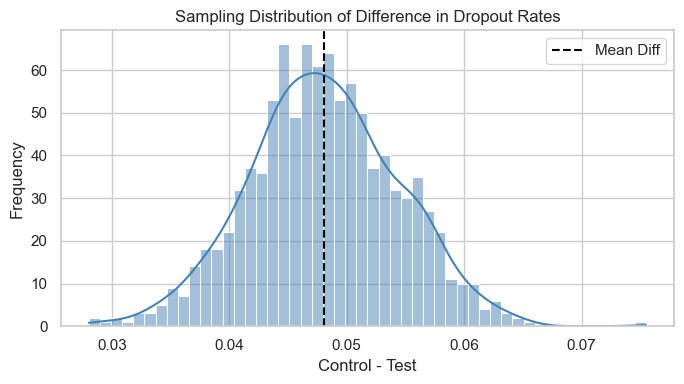

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bootstrap difference in dropout rate between groups
bootstrap_diffs = []
control = df_clean[df_clean['group'] == 'control']['dropout']
test = df_clean[df_clean['group'] == 'test']['dropout']

for _ in range(1000):
    sample_control = control.sample(frac=1, replace=True)
    sample_test = test.sample(frac=1, replace=True)
    diff = sample_control.mean() - sample_test.mean()
    bootstrap_diffs.append(diff)

# Plot sampling distribution
plt.figure(figsize=(7, 4))
sns.histplot(bootstrap_diffs, bins=50, kde=True, color='steelblue')
plt.axvline(np.mean(bootstrap_diffs), color='black', linestyle='--', label='Mean Diff')
plt.title("Sampling Distribution of Difference in Dropout Rates")
plt.xlabel("Control - Test")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


Control group consistently had higher dropout than test group

Most of the distribution is strictly positive (i.e., control − test > 0).

The average improvement is around 5 percentage points, which is substantial in fintech/payment contexts.

The distribution is roughly normal, meaning:

Z-test assumptions (normality of difference in large samples) are valid.

We don't need to rely solely on non-parametric tests.

There’s strong evidence that the retry feature reduces dropouts:

Since the entire distribution lies well above 0 (no overlap around 0), the result is statistically significant.

Confidence interval (if shown) would not include 0.

